# Corn, soybeans, and river-flood exposure near the Des Moines River

This practical sourcing screen combines **2025 USDA Cropland Data Layer** pixels with a bounded, canonical **JRC GloFAS riverine-flood hazard**. The question is intentionally narrow: *which sampled corn and soybean H3 units overlap modeled flood depths, and how does that overlap change from a 10-year to a 100-year event?*

The workflow never downloads a national crop raster or a global flood layer. Icechunk supplies bounded Arrow batches; DuckDB aggregates them out of core; only the small result is materialized. Crop pixels are evidence of land cover—not acreage, yield, ownership, or vulnerability—and flood depth remains a separate hazard measurement rather than a synthetic risk score.

In [1]:
import json
import subprocess
from argparse import Namespace
from pathlib import Path

import h3
import pyarrow.parquet as pq
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

from crc_sdk.workflows import HazardDataset

# GitHub's notebook preview only renders static HTML/images (no JS execution),
# so every fig.show() below emits both an interactive widget and a static PNG fallback.
pio.renderers.default = "jupyterlab+png"

## 1. A bounded, river-adjacent agricultural area

The roughly 5 × 6 km AOI is deliberately small enough for a quick live run but crosses modeled GloFAS flood cells and active corn/soy cover. H3 resolution 7 keeps the crop and hazard layers on the same spatial key.

In [2]:
BOUNDS = (-93.965, 42.030, -93.910, 42.085)
OUTPUT_DIR = REPO_ROOT / 'pipeline_output' / 'agriculture-notebook'
ARTIFACTS_DIR = REPO_ROOT / 'notebooks' / 'artifacts'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

args = Namespace(
    source='usda', bounds=list(BOUNDS), year=2025, crop_codes=[1, 5],
    country_code=None, minimum_confidence=80.0, h3_resolution=7,
    hazard=None, return_periods=[10, 100], cache_mode='reuse',
    output_dir=OUTPUT_DIR, skip_pmtiles=True,
    pmtiles_output=ARTIFACTS_DIR / 'agricultural_crop_flood.pmtiles',
    pmtiles_threads=1,
)
args

Namespace(source='usda', bounds=[-93.965, 42.03, -93.91, 42.085], year=2025, crop_codes=[1, 5], country_code=None, minimum_confidence=80.0, h3_resolution=7, hazard=None, return_periods=[10, 100], cache_mode='reuse', output_dir=PosixPath('/Users/woozyking/rtai/crc-docs/pipeline_output/agriculture-notebook'), skip_pmtiles=True, pmtiles_output=PosixPath('/Users/woozyking/rtai/crc-docs/notebooks/artifacts/agricultural_crop_flood.pmtiles'), pmtiles_threads=1)

## 2. Materialize real GloFAS flood curves

With no pre-supplied hazard file, the twin pipeline resolves the latest GloFAS release, fetches only intersecting source tiles, crops them to the AOI, fits canonical return-period curves, and embeds the source version and probability semantics in Parquet metadata. Running the twin in a clean process also keeps native Icechunk state out of the notebook kernel, so Plotly/Kaleido can reliably emit GitHub-visible PNG fallbacks.

In [3]:
pipeline_command = [
    str(REPO_ROOT / '.venv' / 'bin' / 'python'),
    str(REPO_ROOT / 'pipelines' / 'agricultural_climate_pipeline.py'),
    '--source', 'usda', '--bounds', *map(str, BOUNDS),
    '--year', str(args.year), '--crop-codes', *map(str, args.crop_codes),
    '--return-periods', *map(str, args.return_periods),
    '--h3-resolution', str(args.h3_resolution),
    '--cache-mode', args.cache_mode, '--output-dir', str(OUTPUT_DIR),
    '--pmtiles-output', str(args.pmtiles_output),
]
subprocess.run(pipeline_command, check=True)
hazard_path = OUTPUT_DIR / 'glofas-flood-curves.parquet'
hazard = HazardDataset.local(hazard_path)
hazard_metadata = hazard.metadata()
print(hazard_metadata.model_dump_json(indent=2))

agricultural units: /Users/woozyking/rtai/crc-docs/pipeline_output/agriculture-notebook/usda-agricultural-units.parquet
hazard evaluation: /Users/woozyking/rtai/crc-docs/pipeline_output/agriculture-notebook/usda-hazard-evaluation.parquet
map data: /Users/woozyking/rtai/crc-docs/pipeline_output/agriculture-notebook/usda-crop-flood-map.parquet
summary: /Users/woozyking/rtai/crc-docs/pipeline_output/agriculture-notebook/usda-crop-flood-summary.parquet
pmtiles: skipped
manifest: /Users/woozyking/rtai/crc-docs/pipeline_output/agriculture-notebook/manifest.json


pmtiles: /Users/woozyking/rtai/crc-docs/notebooks/artifacts/agricultural_crop_flood.pmtiles
{
  "schema_version": "1.1",
  "h3_resolution": 7,
  "probability_convention": "non_exceedance",
  "return_period_tail": "upper",
  "return_period_support": [
    10.0,
    500.0
  ],
  "source_probability_support": null,
  "value_unit": "m",
  "value_semantics": "riverine flood depth",
  "geometry_encoding": "WKB",
  "geometry_crs": "EPSG:4326",
  "producer": "crc-sdk",
  "source": {
    "provider": "jrc",
    "dataset": "RiverineInundation:flood_depth",
    "uri": "cems-glofas-river-flood/aoi?bounds=-93.965%2C42.03%2C-93.91%2C42.085&sources=ID36_N50_W100&source_periods=10%2C20%2C50%2C75%2C100%2C200%2C500",
    "version": "2.1.2"
  },
  "fitting": null,
  "creation_version": "0.2.0",
  "row_key": [
    "hazard_name",
    "horizon",
    "pathway",
    "cell_index",
    "source_id"
  ],
  "sort_order": [
    "hazard_name",
    "horizon",
    "pathway",
    "cell_index",
    "source_id"
  ]
}


## 3. Stream crops, evaluate hazard, and publish map artifacts

The remote Icechunk scan is consumed once in the clean pipeline process. DuckDB writes per-H3 crop counts, computes sampled crop shares from that small local aggregate, evaluates only cells covered by the hazard while retaining the unmatched count, and publishes map-ready GeoParquet, summary, manifest, and PMTiles outputs.

In [4]:
agricultural_path = OUTPUT_DIR / 'usda-agricultural-units.parquet'
evaluation_path = OUTPUT_DIR / 'usda-hazard-evaluation.parquet'
map_path = OUTPUT_DIR / 'usda-crop-flood-map.parquet'
summary_path = OUTPUT_DIR / 'usda-crop-flood-summary.parquet'
manifest_path = OUTPUT_DIR / 'manifest.json'
pmtiles_path = args.pmtiles_output
manifest = json.loads(manifest_path.read_text())
matched_rows = manifest['hazard_matched_agricultural_rows']
missing_rows = manifest['hazard_unmatched_agricultural_rows']
print(f'{pq.read_metadata(agricultural_path).num_rows} crop/H3 units')
print(f'{matched_rows} modeled, {missing_rows} outside modeled hazard coverage')
print(f'PMTiles: {pmtiles_path}')

21 crop/H3 units
17 modeled, 4 outside modeled hazard coverage
PMTiles: /Users/woozyking/rtai/crc-docs/notebooks/artifacts/agricultural_crop_flood.pmtiles


## 4. See crop composition and flood overlap

Each hex is labeled by its dominant sampled crop on the left. The right map shows the fitted 100-year riverine-flood depth for modeled cells; gray cells are explicit agricultural observations outside this bounded hazard support. Hovering retains crop share, pixel count, and hazard depth together without collapsing them into a score.

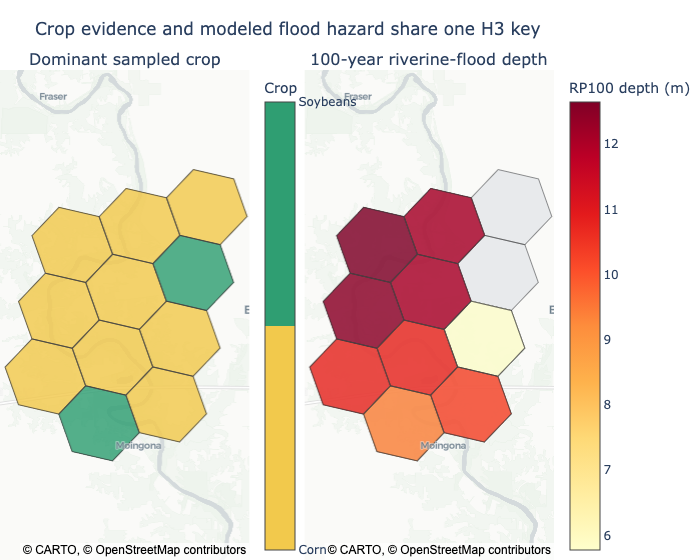

In [5]:
mapped = pq.read_table(map_path).to_pandas()
dominant = (mapped.sort_values('sampled_crop_share', ascending=False)
            .drop_duplicates('cell_index').copy())
dominant['cell_id'] = dominant['cell_index'].astype(str)
dominant['crop_index'] = dominant['crop_name'].map({'Corn': 0, 'Soybeans': 1})
features = []
for cell in dominant['cell_index']:
    boundary = h3.cell_to_boundary(h3.int_to_str(int(cell)))
    coordinates = [[lon, lat] for lat, lon in boundary]
    coordinates.append(coordinates[0])
    features.append({'type': 'Feature', 'id': str(cell), 'properties': {},
                     'geometry': {'type': 'Polygon', 'coordinates': [coordinates]}})
hex_geojson = {'type': 'FeatureCollection', 'features': features}
custom = dominant[['crop_name', 'sampled_crop_share', 'pixel_count',
                   'value_rp10', 'value_rp100', 'hazard_coverage']].to_numpy()
center = {'lon': (BOUNDS[0] + BOUNDS[2]) / 2,
          'lat': (BOUNDS[1] + BOUNDS[3]) / 2}
fig = make_subplots(rows=1, cols=2,
    specs=[[{'type': 'map'}, {'type': 'map'}]],
    subplot_titles=('Dominant sampled crop', '100-year riverine-flood depth'))
fig.add_trace(go.Choroplethmap(
    geojson=hex_geojson, locations=dominant['cell_id'], z=dominant['crop_index'],
    colorscale=[[0, '#f2c94c'], [0.499, '#f2c94c'], [0.5, '#2f9e72'], [1, '#2f9e72']],
    zmin=0, zmax=1, marker_opacity=0.82, marker_line_width=1,
    colorbar={'title': 'Crop', 'tickvals': [0, 1],
              'ticktext': ['Corn', 'Soybeans'], 'x': 0.46},
    customdata=custom,
    hovertemplate='<b>%{customdata[0]}</b><br>sampled crop share %{customdata[1]:.0%}'
                  '<br>sampled pixels %{customdata[2]:,.0f}<extra></extra>'
), row=1, col=1)
fig.add_trace(go.Choroplethmap(
    geojson=hex_geojson, locations=dominant['cell_id'], z=[0] * len(dominant),
    colorscale=[[0, '#d9dde3'], [1, '#d9dde3']], showscale=False,
    marker_opacity=0.55, marker_line_width=1, hoverinfo='skip'
), row=1, col=2)
modeled = dominant[dominant['value_rp100'].notna()]
fig.add_trace(go.Choroplethmap(
    geojson=hex_geojson, locations=modeled['cell_id'], z=modeled['value_rp100'],
    colorscale='YlOrRd', marker_opacity=0.82, marker_line_width=1,
    colorbar={'title': 'RP100 depth (m)', 'x': 1.01},
    customdata=modeled[['crop_name', 'sampled_crop_share',
                        'value_rp10', 'value_rp100']].to_numpy(),
    hovertemplate='<b>%{customdata[0]}</b><br>sampled crop share %{customdata[1]:.0%}'
                  '<br>RP10 %{customdata[2]:.2f} m'
                  '<br>RP100 %{customdata[3]:.2f} m<extra></extra>'
), row=1, col=2)
fig.update_layout(
    title='Crop evidence and modeled flood hazard share one H3 key',
    height=560, margin={'l': 0, 'r': 0, 't': 70, 'b': 0},
    map={'style': 'carto-positron', 'center': center, 'zoom': 10.7},
    map2={'style': 'carto-positron', 'center': center, 'zoom': 10.7},
)
fig.show()

## 5. Compare coverage and return-period implications by crop

The first chart makes missing hazard coverage visible rather than silently dropping it. The second weights flood depth by sampled crop pixels within the modeled overlap; it is an exposure summary, not expected loss.

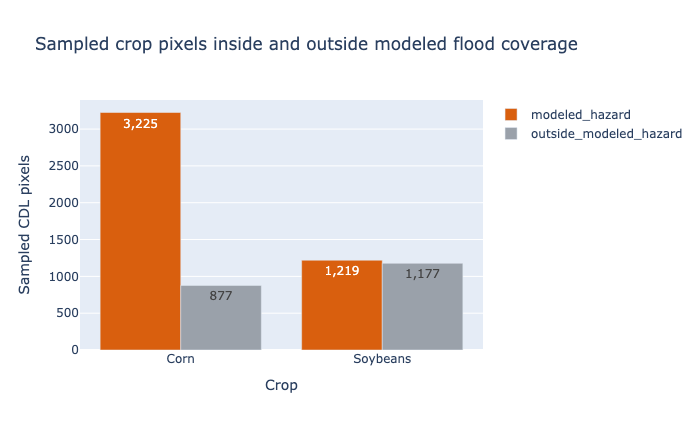

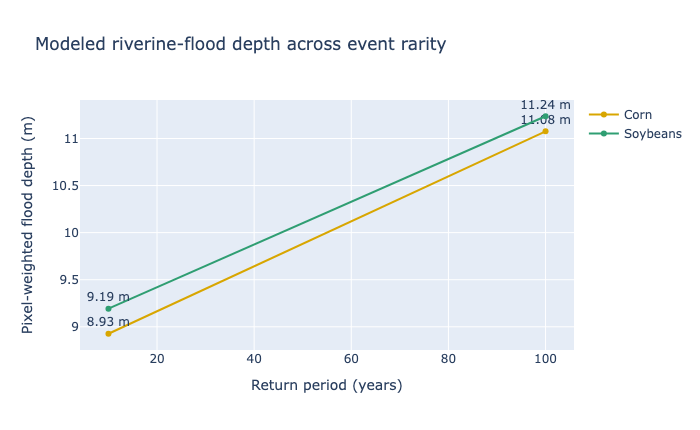

In [6]:
summary = pq.read_table(summary_path).to_pandas()
coverage_fig = px.bar(
    summary, x='crop_name', y='sampled_pixels', color='hazard_coverage',
    barmode='group', text_auto=',.0f',
    color_discrete_map={'modeled_hazard': '#d95f0e',
                        'outside_modeled_hazard': '#9aa1aa'},
    labels={'crop_name': 'Crop', 'sampled_pixels': 'Sampled CDL pixels',
            'hazard_coverage': 'Hazard coverage'},
    title='Sampled crop pixels inside and outside modeled flood coverage',
)
coverage_fig.update_layout(height=430, legend_title_text='')
coverage_fig.show()
evaluated = pq.read_table(evaluation_path).to_pandas()
long = evaluated.melt(
    id_vars=['crop_name', 'pixel_count'], value_vars=['value_rp10', 'value_rp100'],
    var_name='return_period', value_name='depth_m')
long['return_period_years'] = (long['return_period']
    .str.replace('value_rp', '', regex=False).astype(int))
weighted = (long.assign(weighted_depth=lambda d: d.depth_m * d.pixel_count)
            .groupby(['crop_name', 'return_period_years'], as_index=False)
            .agg(weighted_depth=('weighted_depth', 'sum'),
                 sampled_pixels=('pixel_count', 'sum')))
weighted['pixel_weighted_depth_m'] = (
    weighted['weighted_depth'] / weighted['sampled_pixels'])
depth_fig = px.line(
    weighted, x='return_period_years', y='pixel_weighted_depth_m',
    color='crop_name', markers=True, text='pixel_weighted_depth_m',
    color_discrete_map={'Corn': '#d8a600', 'Soybeans': '#2f9e72'},
    labels={'return_period_years': 'Return period (years)',
            'pixel_weighted_depth_m': 'Pixel-weighted flood depth (m)',
            'crop_name': 'Crop'},
    title='Modeled riverine-flood depth across event rarity',
)
depth_fig.update_traces(texttemplate='%{text:.2f} m', textposition='top center')
depth_fig.update_layout(height=430, legend_title_text='')
depth_fig.show()

## Reproducible outputs

- **[Download the layered crop + flood PMTiles archive](artifacts/agricultural_crop_flood.pmtiles)** and open it in [pmtiles.io](https://pmtiles.io). Its `crop_flood` layer retains crop, sampled share, coverage status, and RP10/RP100 depth properties.
- The output directory also contains canonical GloFAS curves, agricultural units, hazard-covered evaluation candidates, the evaluation Parquet, map GeoParquet, summary Parquet, and a checksummed manifest.
- [`pipelines/agricultural_climate_pipeline.py`](../pipelines/agricultural_climate_pipeline.py) is the headless twin.

Interpretation remains deliberately limited: sampled crop composition is not acreage or yield; modeled depth is not damage or loss; gray cells mean *outside this bounded modeled hazard support*, not zero flood risk.